# Using Pre-Trained Transformer Models with Hugging Face

In previous modules, we built and trained neural networks from scratch. That works well for learning,
but in practice the most powerful models today have been trained on enormous datasets (billions of
examples, millions of GPU-hours) that we can't replicate locally.

**Hugging Face** is a platform that hosts thousands of these pre-trained models and makes them easy
to download and use. Think of it like a library: someone else did the expensive work of training;
you just call `pipeline(...)` and run inference on your own input.

This notebook shows you how to:
1. Install the `transformers` library
2. Run a pre-trained model with one line of code (the `pipeline` API)
3. Understand what's actually happening under the hood (tokenization → model → output)
4. Swap in different pre-trained models for different tasks

---
**No training required.** Everything here runs purely on your laptop CPU — the model weights
are downloaded once and cached locally.

## 0. Installation

Run this cell once. After that you can skip it.

In [1]:
# The 'transformers' package is Hugging Face's main library.
# 'sentencepiece' is needed by some tokenizers.
# '!pip install' runs a shell command from inside the notebook.
!pip install transformers sentencepiece

## 1. The Simplest Possible Usage: `pipeline`

The `pipeline` function is Hugging Face's high-level API. You tell it *what task* you want to do,
it picks a good default model, downloads it, and returns a callable object.

We'll start with **sentiment analysis** — given a sentence, decide if it's positive or negative.
This is the 'hello world' of NLP.

In [2]:
from transformers import pipeline

# The first time you run this it will download ~250 MB of model weights.
# After that they're cached in ~/.cache/huggingface/ and load instantly.
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [3]:
# Pass any string — the model returns a label and a confidence score.
result = classifier("The observations matched the theoretical predictions remarkably well.")
print(result)

[{'label': 'POSITIVE', 'score': 0.9995443224906921}]


In [4]:
# You can pass a list of sentences and get back a list of results.
sentences = [
    "The detector noise completely ruined the data.",
    "We finally got a detection — five sigma!",
    "The signal-to-noise ratio was marginal but acceptable.",
]

results = classifier(sentences)

for sentence, res in zip(sentences, results):
    print(f"{res['label']:9s}  ({res['score']:.2%})  →  {sentence}")

# Notice that "five sigma" only scores ~71% positive — lower than you might expect.
# The model was trained on movie reviews and news text; it has no idea that
# "five sigma" is scientific shorthand for a near-certain discovery.
# This is called a domain gap: strong performance on training data doesn't
# guarantee strong performance on text from a different domain.

NEGATIVE   (99.98%)  →  The detector noise completely ruined the data.
POSITIVE   (70.95%)  →  We finally got a detection — five sigma!
NEGATIVE   (82.08%)  →  The signal-to-noise ratio was marginal but acceptable.


## 2. What's Actually Happening Under the Hood

The `pipeline` hides three steps that are always happening:

```
raw text  →  [Tokenizer]  →  integer IDs  →  [Transformer model]  →  logits  →  [Post-processing]  →  answer
```

Let's unpack each step manually using the same model the pipeline chose
(`distilbert-base-uncased-finetuned-sst-2-english`).

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Name of the model — this is how Hugging Face identifies models in its 'Hub'.
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

# AutoTokenizer figures out the right tokenizer class for this model automatically.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# AutoModel similarly picks the right architecture.
# SequenceClassification = the model has a classification head on top.
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

### Step 1: Tokenization

Neural networks can only process numbers, not text. A **tokenizer** converts words (or sub-word
pieces) into integer IDs from a fixed vocabulary.

Physics analogy: it's like discretizing a continuous field onto a grid before solving numerically.

In [6]:
# Use a sentence with long scientific words to show sub-word tokenization clearly.
text = "The astrophysical observations were electromagnetically significant."

# return_tensors='pt' means return PyTorch tensors (pt = pytorch)
inputs = tokenizer(text, return_tensors="pt")

print("Keys in tokenizer output:", list(inputs.keys()))
print()
print("Token IDs:", inputs["input_ids"])
print()

# Convert IDs back to tokens so you can see how the text was split
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Tokens:   ", tokens)
print()
print("Note: [CLS] and [SEP] are special markers the model was trained to expect.")
print("'##' prefix means a sub-word piece that continues the previous token.")
print("Long or rare words get split into pieces the model has seen during training.")

Keys in tokenizer output: ['input_ids', 'attention_mask']

Token IDs: tensor([[  101,  1996, 28625, 23302,  9420,  2020, 17225,  3973,  3278,  1012,
           102]])

Tokens:    ['[CLS]', 'the', 'astro', '##physical', 'observations', 'were', 'electromagnetic', '##ally', 'significant', '.', '[SEP]']

Note: [CLS] and [SEP] are special markers the model was trained to expect.
'##' prefix means a sub-word piece that continues the previous token.
Long or rare words get split into pieces the model has seen during training.


### Step 2: Running the Model

The tokenized input is fed through the transformer. The output `logits` are raw (unnormalized)
scores for each class — exactly like the final linear layer in our MLP from Module 1.

In [7]:
# torch.no_grad() tells PyTorch not to build a computation graph.
# We're only doing forward inference, not training, so we don't need gradients.
# This saves memory and runs faster.
with torch.no_grad():
    outputs = model(**inputs)  # ** unpacks the dict as keyword arguments

logits = outputs.logits
print("Raw logits:", logits)
print("Shape:", logits.shape)  # (batch_size=1, num_classes=2)

Raw logits: tensor([[-3.5776,  3.7512]])
Shape: torch.Size([1, 2])


### Step 3: Post-processing

Turn logits into probabilities with softmax, then pick the highest-probability class.

In [8]:
import torch.nn.functional as F

probs = F.softmax(logits, dim=-1)

# model.config.id2label maps integer class IDs to human-readable labels
labels = model.config.id2label
print("Class labels:", labels)
print()

for class_id, prob in enumerate(probs[0]):
    print(f"  {labels[class_id]:9s}: {prob.item():.2%}")

predicted_class = probs.argmax().item()
print(f"\nPrediction: {labels[predicted_class]}")

Class labels: {0: 'NEGATIVE', 1: 'POSITIVE'}

  NEGATIVE : 0.07%
  POSITIVE : 99.93%

Prediction: POSITIVE


## 3. Other Tasks and Models

The `pipeline` API supports many tasks. You just change the task string (and optionally specify
a model). Hugging Face will download the appropriate pre-trained weights.

Here are a few tasks relevant to scientific work.

### 3a. Zero-Shot Classification

Classify text into *any categories you define at runtime* — no fine-tuning needed.
The model figures out whether each label is a plausible description of the input.

This works by training on a "natural language inference" task: *does sentence A entail sentence B?*

In [9]:
# This model is larger (~1.5 GB) — comment out if you're on a slow connection.
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

abstract = """
We report a measurement of the cosmic microwave background power spectrum using data
from the South Pole Telescope. The results are consistent with a ΛCDM cosmological model
with the following best-fit parameters: H0 = 67.4 km/s/Mpc, Ωm = 0.315.
"""

# Define candidate labels — these are completely custom, not fixed by the model
candidate_labels = ["cosmology", "particle physics", "optics", "materials science", "biology"]

result = zero_shot(abstract, candidate_labels=candidate_labels)

print("Scores for each label:")
for label, score in zip(result["labels"], result["scores"]):
    bar = "█" * int(score * 40)
    print(f"  {label:20s} {score:.3f}  {bar}")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Scores for each label:
  cosmology            0.546  █████████████████████
  optics               0.202  ████████
  biology              0.114  ████
  particle physics     0.092  ███
  materials science    0.046  █


### 3b. Question Answering

Give the model a **context passage** and a **question**; it extracts the answer span from the passage.

Useful for quickly querying long documents.

In [10]:
qa = pipeline("question-answering")

context = """
The James Webb Space Telescope (JWST) was launched on December 25, 2021, and reached its
operational orbit at the second Sun-Earth Lagrange point (L2) in January 2022. It observes
primarily in the infrared, with wavelengths ranging from 0.6 to 28 micrometers. The primary
mirror has a diameter of 6.5 meters, composed of 18 hexagonal beryllium segments coated in gold.
"""

questions = [
    "When was JWST launched?",
    "What is the diameter of the primary mirror?",
    "What wavelengths does JWST observe?",
]

for q in questions:
    answer = qa(question=q, context=context)
    print(f"Q: {q}")
    print(f"A: {answer['answer']}  (confidence: {answer['score']:.2%})")
    print()

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Q: When was JWST launched?
A: December 25, 2021  (confidence: 98.57%)

Q: What is the diameter of the primary mirror?
A: 6.5 meters  (confidence: 98.03%)

Q: What wavelengths does JWST observe?
A: 0.6 to 28 micrometers  (confidence: 81.31%)



### 3c. Text Generation (GPT-2)

Given a prompt, continue the text. GPT-2 is a small but historically important model —
it's the same architecture that scaled up into GPT-3/4.

We built a transformer from scratch in Module 03 (Shakespeare). This is the same thing,
just trained on a much larger and more diverse corpus.

In [11]:
generator = pipeline("text-generation", model="gpt2")

prompt = "The black hole at the center of our galaxy is known to have a mass of"

# max_new_tokens: how many tokens to generate beyond the prompt
# num_return_sequences: generate this many independent completions
# do_sample=True: sample from the distribution rather than always taking the most likely token
# temperature: controls randomness. Low temp (0.3) = more focused. High temp (1.5) = more creative.
outputs = generator(
    prompt,
    max_new_tokens=60,
    num_return_sequences=3,
    do_sample=True,
    temperature=0.9,
    pad_token_id=50256,  # GPT-2 doesn't have a pad token; this suppresses a warning
)

for i, output in enumerate(outputs):
    print(f"--- Completion {i+1} ---")
    print(output["generated_text"])
    print()

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


--- Completion 1 ---
The black hole at the center of our galaxy is known to have a mass of about 1.7 trillion light-years.

As of this writing, it has been discovered that there are 10,000 galaxies that share 4 billion of these 8,000 galaxies, and about half of the galaxies in the Milky Way are in white dwarf systems.

The discovery is the

--- Completion 2 ---
The black hole at the center of our galaxy is known to have a mass of roughly 8.8 billion light years (3) with a black hole radius of 5.5 trillion km (3), and to have a core of 100 astronomical units (ALT) that has a mass of around 2.5 GW (1). The Kuiper Belt is the most densely populated

--- Completion 3 ---
The black hole at the center of our galaxy is known to have a mass of 3.7×106 times that of the sun.

This is about the size of Saturn. The black hole is about a millionth as big as the sun, while our galaxy is about a billionth as big as our galaxy.

At the same time, the black hole's



## 4. Exploring the Model Hub

Everything above used default or well-known model names. On [huggingface.co/models](https://huggingface.co/models)
you can filter by:
- **Task** (text classification, translation, image classification, ...)
- **Library** (PyTorch, TensorFlow, ...)
- **Language**
- **Dataset** the model was trained on

Any model page shows you exactly how to load it. For example, if the page shows:
```python
model = AutoModel.from_pretrained("some-org/some-model-name")
```
that string is the model's identifier, and you can drop it into `pipeline(model="...")` directly.

Below: a quick demo of swapping in a different sentiment model.

In [12]:
# 'cardiffnlp/twitter-roberta-base-sentiment-latest' was fine-tuned on Twitter data.
# It predicts three classes instead of two: Negative / Neutral / Positive.
twitter_classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

tweets = [
    "just got first light on the telescope. wow.",
    "proposal rejected again. third time this year",
    "conference talk went okay I guess",
]

results = twitter_classifier(tweets)
for tweet, res in zip(tweets, results):
    print(f"{res['label']:10s} ({res['score']:.2%})  →  {tweet}")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


positive   (87.96%)  →  just got first light on the telescope. wow.
negative   (90.85%)  →  proposal rejected again. third time this year
positive   (76.28%)  →  conference talk went okay I guess


## 5. Comparing Models: Confidence vs. Correctness

Models can be confidently wrong. Here's a mini experiment: give both classifiers the same sentences
and see where they agree or disagree.

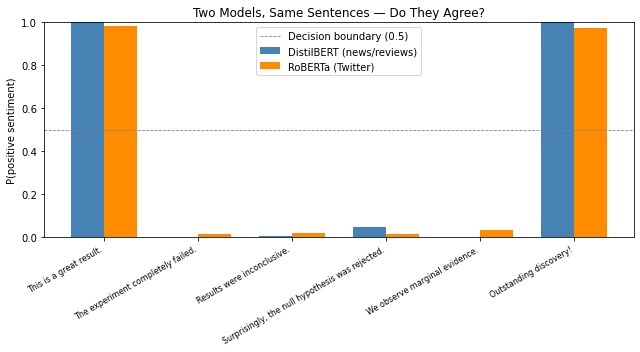

In [13]:
import matplotlib.pyplot as plt
import numpy as np

test_sentences = [
    "This is a great result.",
    "The experiment completely failed.",
    "Results were inconclusive.",
    "Surprisingly, the null hypothesis was rejected.",
    "We observe marginal evidence.",
    "Outstanding discovery!",
]

# Collect scores from both models.
# For the two-class model, we want the POSITIVE score.
# For the three-class model, we also want specifically the POSITIVE score.
# We use top_k=None to get scores for ALL classes at once, so we can
# look up "positive" directly — otherwise, if the top class is "neutral",
# we'd have no clean way to extract the positive probability.
scores_default = []
scores_twitter = []

for sent in test_sentences:
    r1 = classifier(sent)[0]
    # Two-class model: if top label is NEGATIVE, positive score = 1 - confidence
    pos_score_1 = r1['score'] if r1['label'] == 'POSITIVE' else 1 - r1['score']
    scores_default.append(pos_score_1)

    # Three-class model: get all three scores and find the one labeled 'positive'
    all_scores = twitter_classifier(sent, top_k=None)
    pos_score_2 = next(s['score'] for s in all_scores if 'positive' in s['label'].lower())
    scores_twitter.append(pos_score_2)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(test_sentences))
width = 0.35

bars1 = ax.bar(x - width/2, scores_default, width, label='DistilBERT (news/reviews)', color='steelblue')
bars2 = ax.bar(x + width/2, scores_twitter, width, label='RoBERTa (Twitter)', color='darkorange')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Decision boundary (0.5)')
ax.set_ylabel('P(positive sentiment)')
ax.set_title('Two Models, Same Sentences — Do They Agree?')
ax.set_xticks(x)
ax.set_xticklabels(test_sentences, rotation=30, ha='right', fontsize=8)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Concept | What it is |
|---|---|
| `pipeline(task)` | One-line interface; handles tokenization + model + post-processing |
| `AutoTokenizer` | Converts text → integer IDs the model can process |
| `AutoModel` | Loads pre-trained weights; `from_pretrained` downloads if not cached |
| Model Hub | [huggingface.co/models](https://huggingface.co/models) — thousands of models, searchable by task |
| `logits → softmax → probs` | Same last step as our MLP — the transformer is just a much richer feature extractor |

**Where models live on your laptop:** `~/.cache/huggingface/hub/`  
Downloaded weights persist between sessions — you only pay the download cost once.

**Next steps to explore:**
- Try a domain-specific model (e.g., `allenai/scibert_scivocab_uncased` for scientific text)
- Use `pipeline("feature-extraction")` to get raw embeddings — useful for similarity search
- Fine-tune a pre-trained model on your own labeled dataset (transfer learning)